# VEO Descriptive Analysis

Comprehensive descriptive analysis of generative model (VEO) performance on visual search tasks including success rates, failure type distributions, and generative fidelity metrics.

**Key Output Variable**: `generative_success` - per-bin per-condition average success rate (main dependent variable for downstream hypothesis testing)

In [2]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scipy 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

  Obtaining dependency information for pandas from https://files.pythonhosted.org/packages/35/d0/4831af68ce30cc2d03c697bea8450e3225a835ef497d0d70f31b8cdde965/pandas-3.0.2-cp312-cp312-macosx_11_0_arm64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.3 MB/s eta 0:00:00-:--:--
  Obtaining dependency information for numpy from https://files.pythonhosted.org/packages/9b/fd/e5ecca1e78c05106d98028114f5c00d3eddb41207686b2b7de3e477b0e22/numpy-2.4.4-cp312-cp312-macosx_14_0_arm64.whl.metadata
  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/7e/65/07d5f5c7f7c994f12c768708bd2e17a4f01a2b0f44a1c9eccad872433e2e/matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.7 MB/s eta 0:00:00
  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-a

In [3]:
# Load VEO results data
veo_data = pd.read_csv('../veo_results/mergedVeo3.csv')
print(f"Data loaded: {veo_data.shape[0]} rows, {veo_data.shape[1]} columns")
print(f"\nColumns: {veo_data.columns.tolist()}")
print(f"\nFirst few rows:")
print(veo_data.head())

Data loaded: 114 rows, 53 columns

Columns: ['video_filename', 'condition', 'bin_x', 'source_image', 'status', 'image_condition', 'shape_type', 'target', 'center_x', 'center_y', 'size', 'color', 'quadrant', 'row', 'column', 'num_distractors', 'num_images', 'distractor_color', 'color_bin_index', 'rotation_angle', 'bin_group', 'trial_index', 'condition.1', 'bin_y', 'sample', 'success', 'failure_type', 'err_no_distractors', 'err_no_target', 'err_wrong_manip', 'err_new_target_id', 'err_new_target_unid', 'err_extra_distractors', 'err_font_change', 'err_rotation', 'err_movement', 'err_enlarge_target', 'err_enlarge_distractors', 'err_target_centre', 'err_circular_motion', 'err_merging', 'err_other', 'err_id_change_before', 'err_id_change_after', 'err_vanishing', 'fidelity_score_total', 'fidelity_omission', 'fidelity_numeric', 'fidelity_temporal', 'fidelity_physical_vanishing', 'notes', 'coder', 'timestamp']

First few rows:
                   video_filename      condition  bin_x  source_image

In [5]:
# Data Overview and Exploration
print("=" * 60)
print("DATA OVERVIEW")
print("=" * 60)
print(f"\nUnique conditions: {sorted(veo_data['condition'].unique())}")
print(f"Number of unique conditions: {veo_data['condition'].nunique()}")
print(f"\nUnique bins: {sorted(veo_data['bin_y'].unique())}")
print(f"Number of unique bins: {veo_data['bin_y'].nunique()}")
print(f"\nMissing values:\n{veo_data.isnull().sum()}")
print(f"\nSuccess distribution:\n{veo_data['success'].value_counts()}")
print(f"\nSuccess rate (overall): {veo_data['success'].mean():.3f}")

# Check failure types
failure_types = veo_data[veo_data['success']==0]['failure_type'].unique()
failure_types_sorted = sorted([ft for ft in failure_types if pd.notna(ft)])
print(f"\nFailure types: {failure_types_sorted}")
print(f"Failure type counts:\n{veo_data[veo_data['success']==0]['failure_type'].value_counts()}")

DATA OVERVIEW

Unique conditions: ['2Among5Colour', '2Among5ConjRed', '2Among5NoColour', 'NoDistractors']
Number of unique conditions: 4

Unique bins: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Number of unique bins: 7

Missing values:
video_filename                   0
condition                        0
bin_x                            0
source_image                     0
status                           0
image_condition                  0
shape_type                       0
target                           0
center_x                         0
center_y                         0
size                             0
color                            0
quadrant                         0
row                              0
column                           0
num_distractors                  0
num_images                       0
distractor_color                 0
color_bin_index                  0
rotation_angle                   0
bin_group      

## 1. Overall Success Rate

In [6]:
overall_success = veo_data['success'].mean()
n_success = veo_data['success'].sum()
n_total = len(veo_data)

print("=" * 60)
print("OVERALL SUCCESS RATE")
print("=" * 60)
print(f"Success Rate: {overall_success:.4f}")
print(f"Successes: {int(n_success)}")
print(f"Total Trials: {n_total}")
print(f"Failures: {int(n_total - n_success)}")

OVERALL SUCCESS RATE
Success Rate: 0.2982
Successes: 34
Total Trials: 114
Failures: 80


## 2. Generative Success: Per Bin Per Condition (Main DV)

In [7]:
print("=" * 60)
print("GENERATIVE SUCCESS BY CONDITION AND BIN")
print("=" * 60)

# Calculate generative_success: average success rate per bin per condition
generative_success = veo_data.groupby(['condition', 'bin_y'])['success'].agg(
    ['mean', 'sum', 'count', 'std']
).reset_index()

generative_success.columns = ['condition', 'bin', 'generative_success', 'n_success', 'n_total', 'std_success']

# Calculate 95% CI for each bin-condition combination
ci_lower = []
ci_upper = []
for idx, row in generative_success.iterrows():
    p = row['generative_success']
    n = row['n_total']
    se = np.sqrt(p * (1 - p) / n) if n > 0 else 0
    ci_lower.append(p - 1.96 * se)
    ci_upper.append(p + 1.96 * se)

generative_success['ci_lower'] = ci_lower
generative_success['ci_upper'] = ci_upper

print("\nGenerative Success Rates (per Condition × Bin):")
print(generative_success.to_string(index=False))

# Export to CSV for downstream analysis
generative_success.to_csv('../Analysis/generative_success.csv', index=False)
print("\n✓ Saved to: Analysis/generative_success.csv")

GENERATIVE SUCCESS BY CONDITION AND BIN

Generative Success Rates (per Condition × Bin):
      condition  bin  generative_success  n_success  n_total  std_success  ci_lower  ci_upper
  2Among5Colour    1            0.833333          5        6     0.408248  0.535129  1.131538
  2Among5Colour    2            0.666667          4        6     0.516398  0.289464  1.043869
  2Among5Colour    3            0.333333          2        6     0.516398 -0.043869  0.710536
  2Among5Colour    4            0.333333          2        6     0.516398 -0.043869  0.710536
  2Among5Colour    5            0.166667          1        6     0.408248 -0.131538  0.464871
  2Among5Colour    6            0.500000          3        6     0.547723  0.099917  0.900083
 2Among5ConjRed    1            0.833333          5        6     0.408248  0.535129  1.131538
 2Among5ConjRed    2            0.000000          0        6     0.000000  0.000000  0.000000
 2Among5ConjRed    3            0.166667          1        6     

## 3. Success Rate by Condition

In [8]:
success_by_condition = veo_data.groupby('condition')['success'].agg(
    ['mean', 'sum', 'count']
).reset_index()
success_by_condition.columns = ['condition', 'success_rate', 'n_success', 'n_total']

print("\nSuccess Rate by Condition:")
print(success_by_condition.to_string(index=False))

# Also by bin (collapsed across conditions)
success_by_bin = veo_data.groupby('bin_y')['success'].agg(
    ['mean', 'sum', 'count']
).reset_index()
success_by_bin.columns = ['bin', 'success_rate', 'n_success', 'n_total']

print("\n\nSuccess Rate by Bin (Overall):")
print(success_by_bin.to_string(index=False))


Success Rate by Condition:
      condition  success_rate  n_success  n_total
  2Among5Colour      0.472222         17       36
 2Among5ConjRed      0.166667          6       36
2Among5NoColour      0.138889          5       36
  NoDistractors      1.000000          6        6


Success Rate by Bin (Overall):
 bin  success_rate  n_success  n_total
   0      1.000000          6        6
   1      0.777778         14       18
   2      0.222222          4       18
   3      0.222222          4       18
   4      0.111111          2       18
   5      0.055556          1       18
   6      0.166667          3       18


## 4. Failure Type Distribution

In [9]:
print("=" * 60)
print("FAILURE TYPE ANALYSIS")
print("=" * 60)

# Overall failure type distribution
failures = veo_data[veo_data['success'] == 0].copy()
total_failures = len(failures)
print(f"\nTotal Failures: {total_failures}")

failure_type_dist = failures['failure_type'].value_counts(dropna=False)
print("\nOverall Failure Type Distribution (Counts):")
print(failure_type_dist)

failure_pct = failures['failure_type'].value_counts(normalize=True, dropna=False) * 100
print("\nOverall Failure Type Distribution (%):")
for ft, pct in failure_pct.items():
    print(f"  {ft}: {pct:.2f}%")

# Failure types by condition
print("\n\nFailure Types by Condition:")
failure_by_condition = failures.groupby(['condition', 'failure_type']).size().reset_index(name='count')
print(failure_by_condition.to_string(index=False))

# Failure types by bin
print("\n\nFailure Types by Bin:")
failure_by_bin = failures.groupby(['bin_y', 'failure_type']).size().reset_index(name='count')
print(failure_by_bin.to_string(index=False))

FAILURE TYPE ANALYSIS

Total Failures: 80

Overall Failure Type Distribution (Counts):
failure_type
new_generation    61
ambiguity         14
NaN                3
location           2
Name: count, dtype: int64

Overall Failure Type Distribution (%):
  new_generation: 76.25%
  ambiguity: 17.50%
  nan: 3.75%
  location: 2.50%


Failure Types by Condition:
      condition   failure_type  count
  2Among5Colour      ambiguity     11
  2Among5Colour new_generation      7
 2Among5ConjRed      ambiguity      1
 2Among5ConjRed       location      1
 2Among5ConjRed new_generation     26
2Among5NoColour      ambiguity      2
2Among5NoColour       location      1
2Among5NoColour new_generation     28


Failure Types by Bin:
 bin_y   failure_type  count
     1      ambiguity      1
     1 new_generation      3
     2      ambiguity      1
     2       location      1
     2 new_generation     12
     3      ambiguity      3
     3 new_generation     11
     4      ambiguity      4
     4       loca

## 5. Generative Fidelity

In [10]:
# Identify fidelity columns
fidelity_cols = [col for col in veo_data.columns if 'fidelity' in col.lower()]
print(f"Fidelity columns identified: {fidelity_cols}")

print("\n" + "=" * 60)
print("FIDELITY DESCRIPTIVE STATISTICS (OVERALL)")
print("=" * 60)
print("\n", veo_data[fidelity_cols].describe().round(4))

# Fidelity by success/failure
print("\n" + "=" * 60)
print("FIDELITY BY SUCCESS/FAILURE STATUS")
print("=" * 60)
fidelity_by_success = veo_data.groupby('success')[fidelity_cols].agg(['mean', 'std', 'min', 'max'])
print("\n", fidelity_by_success.round(4))

# Fidelity by condition
print("\n" + "=" * 60)
print("FIDELITY BY CONDITION")
print("=" * 60)
fidelity_by_condition = veo_data.groupby('condition')[fidelity_cols].mean().round(4)
print("\n", fidelity_by_condition)

# Fidelity by bin
print("\n" + "=" * 60)
print("FIDELITY BY BIN")
print("=" * 60)
fidelity_by_bin = veo_data.groupby('bin_y')[fidelity_cols].mean().round(4)
print("\n", fidelity_by_bin)

Fidelity columns identified: ['fidelity_score_total', 'fidelity_omission', 'fidelity_numeric', 'fidelity_temporal', 'fidelity_physical_vanishing']

FIDELITY DESCRIPTIVE STATISTICS (OVERALL)

        fidelity_score_total  fidelity_omission  fidelity_numeric  \
count              114.0000           114.0000          114.0000   
mean                 4.9035             0.0789            1.1579   
std                  1.9596             0.2708            0.9647   
min                  1.0000             0.0000            0.0000   
25%                  4.0000             0.0000            0.0000   
50%                  5.0000             0.0000            1.0000   
75%                  6.0000             0.0000            2.0000   
max                 10.0000             1.0000            3.0000   

       fidelity_temporal  fidelity_physical_vanishing  
count           114.0000                     114.0000  
mean              3.4474                       0.2193  
std               1.3832   

## 6. Additional Descriptive Statistics

In [12]:
print("\n" + "=" * 60)
print("ADDITIONAL DESCRIPTIVE STATISTICS")
print("=" * 60)

# 6a. Success by number of distractors (if column exists)
if 'num_distractors' in veo_data.columns:
    print("\n--- Success Rate by Number of Distractors ---")
    distractor_success = veo_data.groupby('num_distractors')['success'].agg(
        ['mean', 'sum', 'count']
    ).reset_index()
    distractor_success.columns = ['num_distractors', 'success_rate', 'n_success', 'n_total']
    print(distractor_success.to_string(index=False))

# 6b. Effect size (Cohen's h) for success between conditions
print("\n--- Effect Sizes (Cohen's h) Between Conditions ---")
conditions = success_by_condition['condition'].values
for i in range(len(conditions)):
    for j in range(i+1, len(conditions)):
        c1_success = success_by_condition.iloc[i]['success_rate']
        c2_success = success_by_condition.iloc[j]['success_rate']
        h = 2 * (np.arcsin(np.sqrt(c1_success)) - np.arcsin(np.sqrt(c2_success)))
        print(f"  {conditions[i]} vs {conditions[j]}: h = {h:.4f}")

# 6c. Trial count distribution
print("\n--- Trial Count by Condition and Bin ---")
trial_counts = veo_data.groupby(['condition', 'bin_y']).size().reset_index(name='count')
trial_counts_pivot = trial_counts.pivot(index='condition', columns='bin_y', values='count')
print(trial_counts_pivot)

# 6d. Success rate stability (coefficient of variation within conditions)
print("\n--- Success Rate Variability within Conditions (Bin-level) ---")
for condition in veo_data['condition'].unique():
    cond_data = generative_success[generative_success['condition'] == condition]
    bin_success_rates = cond_data['generative_success'].values
    if len(bin_success_rates) > 1:
        cv = np.std(bin_success_rates) / np.mean(bin_success_rates)
        range_val = bin_success_rates.max() - bin_success_rates.min()
        print(f"  {condition}: CV = {cv:.4f}, Range = [{bin_success_rates.min():.4f}, {bin_success_rates.max():.4f}]")


ADDITIONAL DESCRIPTIVE STATISTICS

--- Success Rate by Number of Distractors ---
 num_distractors  success_rate  n_success  n_total
               0      1.000000          6        6
               1      1.000000          4        4
               2      0.833333          5        6
               3      1.000000          2        2
               4      0.500000          3        6
               5      0.400000          2        5
               6      0.250000          2        8
               7      0.000000          0        2
               8      0.000000          0        3
               9      0.285714          2        7
              10      0.666667          2        3
              11      0.000000          0        2
              12      0.000000          0        1
              14      0.000000          0        4
              16      0.000000          0        1
              17      0.000000          0        3
              20      0.000000          0        1


## 7. Visualizations <- to be determined !

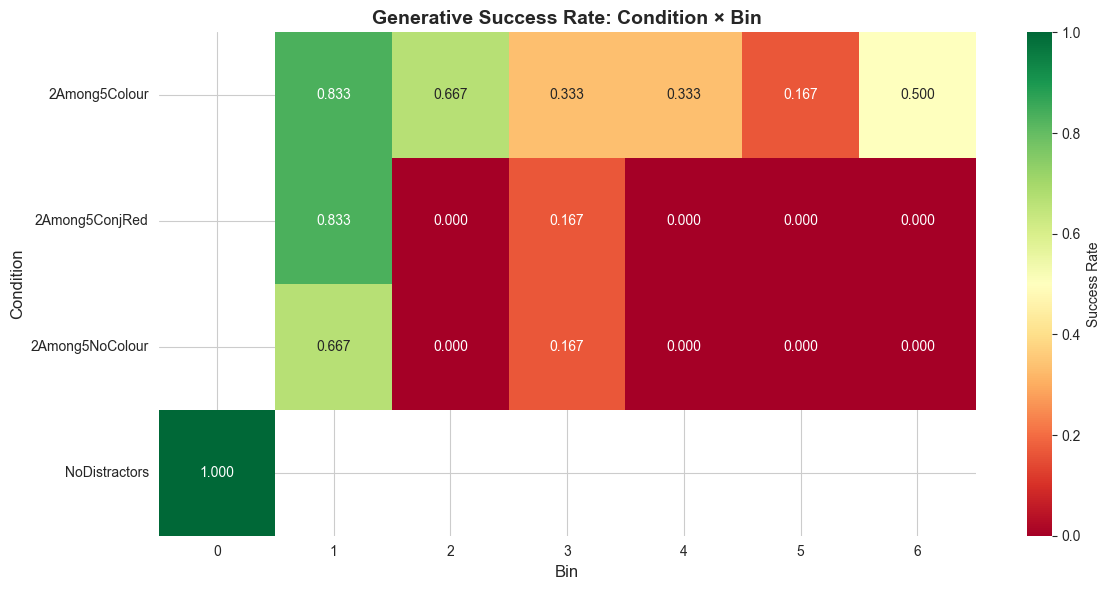

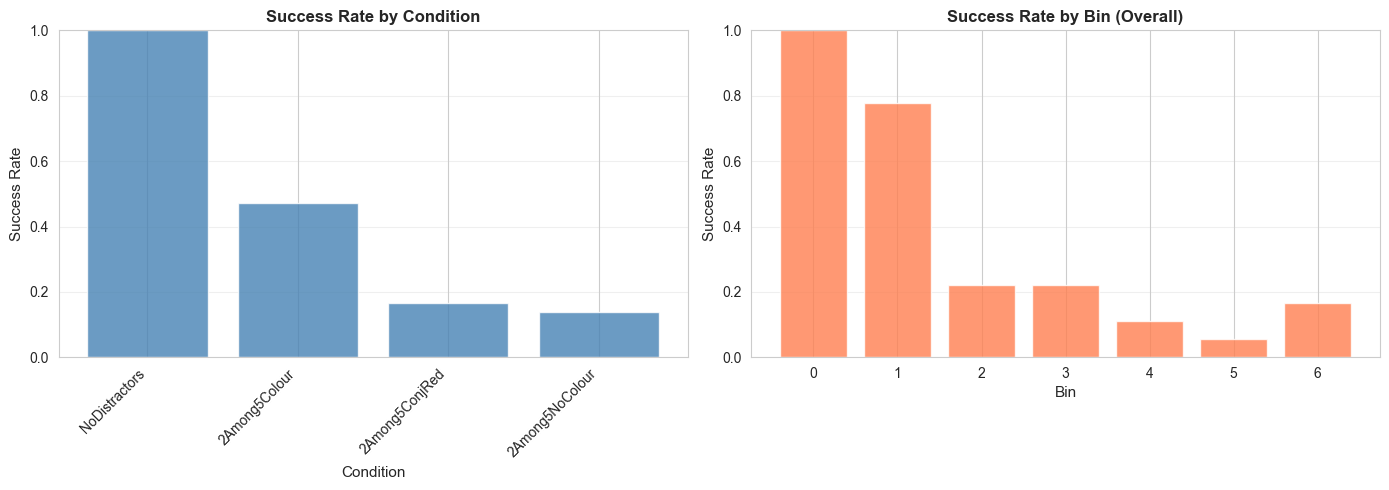

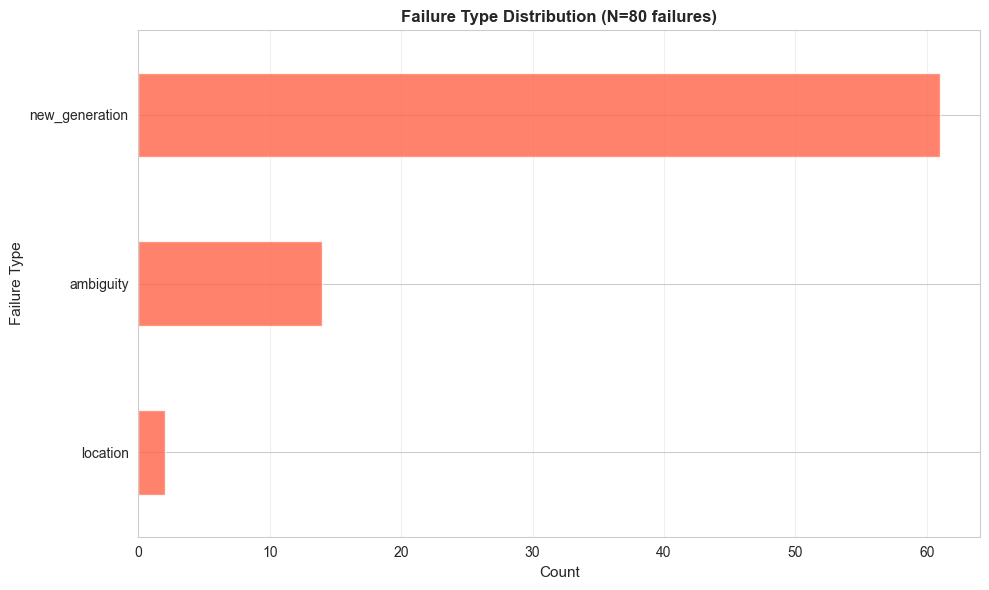

In [13]:
# 7a: Generative Success Heatmap (Condition × Bin)
pivot_success = generative_success.pivot(index='condition', columns='bin', values='generative_success')
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot_success, annot=True, fmt='.3f', cmap='RdYlGn', cbar_kws={'label': 'Success Rate'},
            vmin=0, vmax=1, ax=ax)
ax.set_title('Generative Success Rate: Condition × Bin', fontsize=14, fontweight='bold')
ax.set_ylabel('Condition', fontsize=12)
ax.set_xlabel('Bin', fontsize=12)
plt.tight_layout()
plt.show()

# 7b: Success rate by condition (bar plot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar 1: Success by condition
success_by_condition_sorted = success_by_condition.sort_values('success_rate', ascending=False)
axes[0].bar(range(len(success_by_condition_sorted)), success_by_condition_sorted['success_rate'].values,
           color='steelblue', alpha=0.8)
axes[0].set_xticks(range(len(success_by_condition_sorted)))
axes[0].set_xticklabels(success_by_condition_sorted['condition'].values, rotation=45, ha='right')
axes[0].set_ylabel('Success Rate', fontsize=11)
axes[0].set_xlabel('Condition', fontsize=11)
axes[0].set_title('Success Rate by Condition', fontsize=12, fontweight='bold')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# Bar 2: Success by bin
success_by_bin_sorted = success_by_bin.sort_values('bin')
axes[1].bar(range(len(success_by_bin_sorted)), success_by_bin_sorted['success_rate'].values,
           color='coral', alpha=0.8)
axes[1].set_xticks(range(len(success_by_bin_sorted)))
axes[1].set_xticklabels(success_by_bin_sorted['bin'].values, rotation=0)
axes[1].set_ylabel('Success Rate', fontsize=11)
axes[1].set_xlabel('Bin', fontsize=11)
axes[1].set_title('Success Rate by Bin (Overall)', fontsize=12, fontweight='bold')
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 7c: Failure type distribution
failure_counts = failures['failure_type'].value_counts()
fig, ax = plt.subplots(figsize=(10, 6))
failure_counts.sort_values().plot(kind='barh', ax=ax, color='tomato', alpha=0.8)
ax.set_title(f'Failure Type Distribution (N={len(failures)} failures)', fontsize=12, fontweight='bold')
ax.set_xlabel('Count', fontsize=11)
ax.set_ylabel('Failure Type', fontsize=11)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

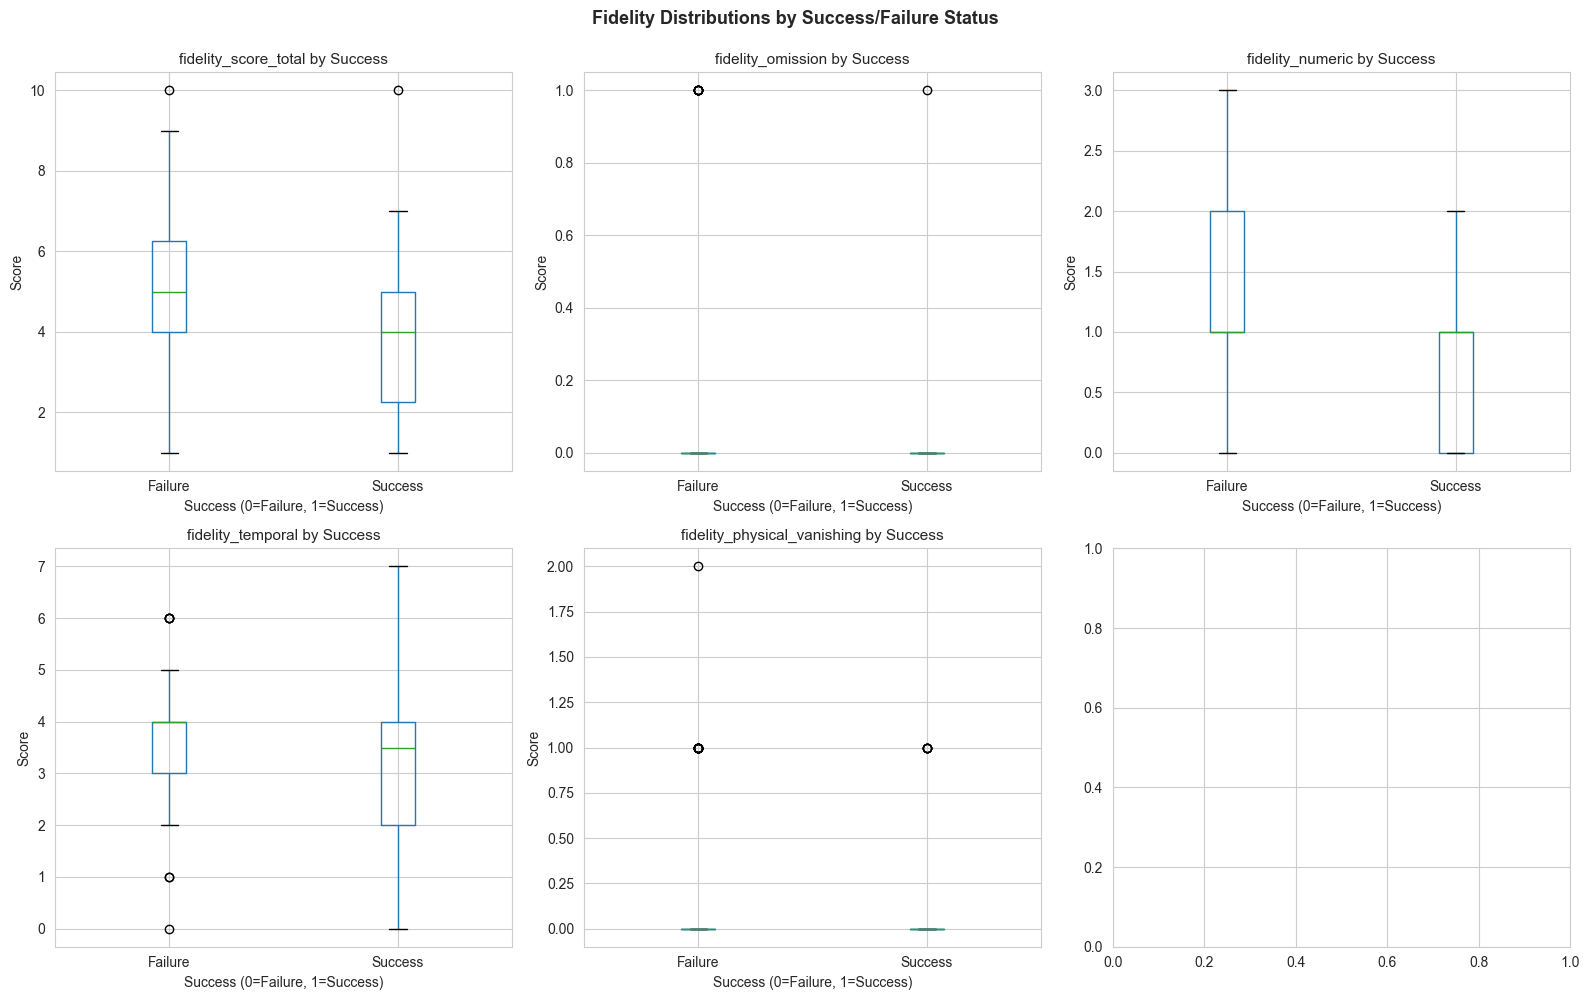

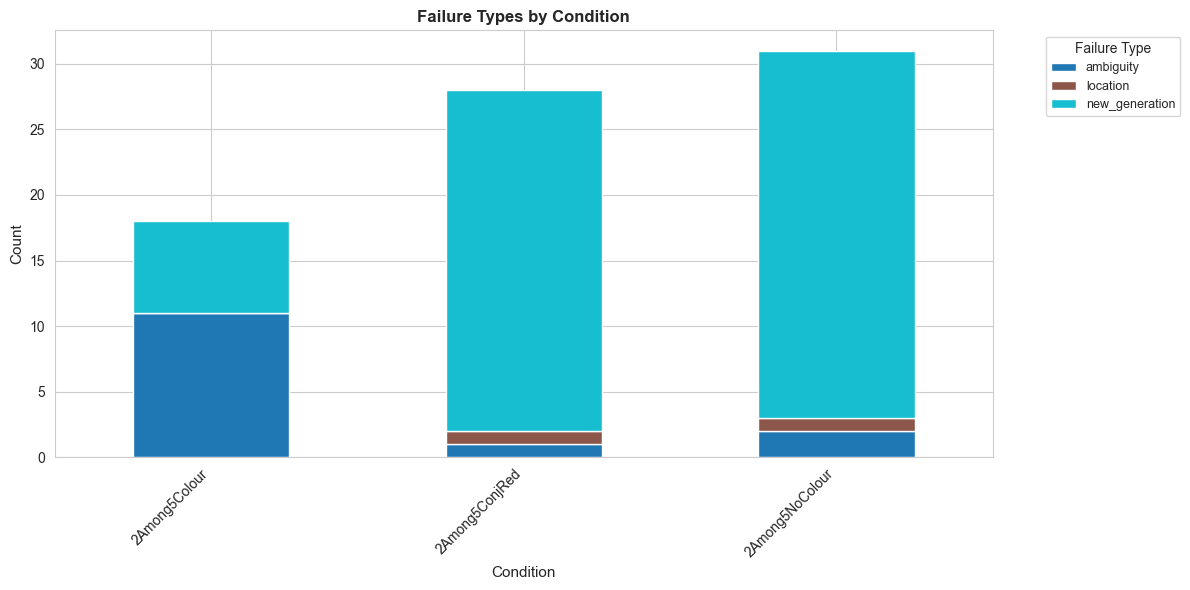

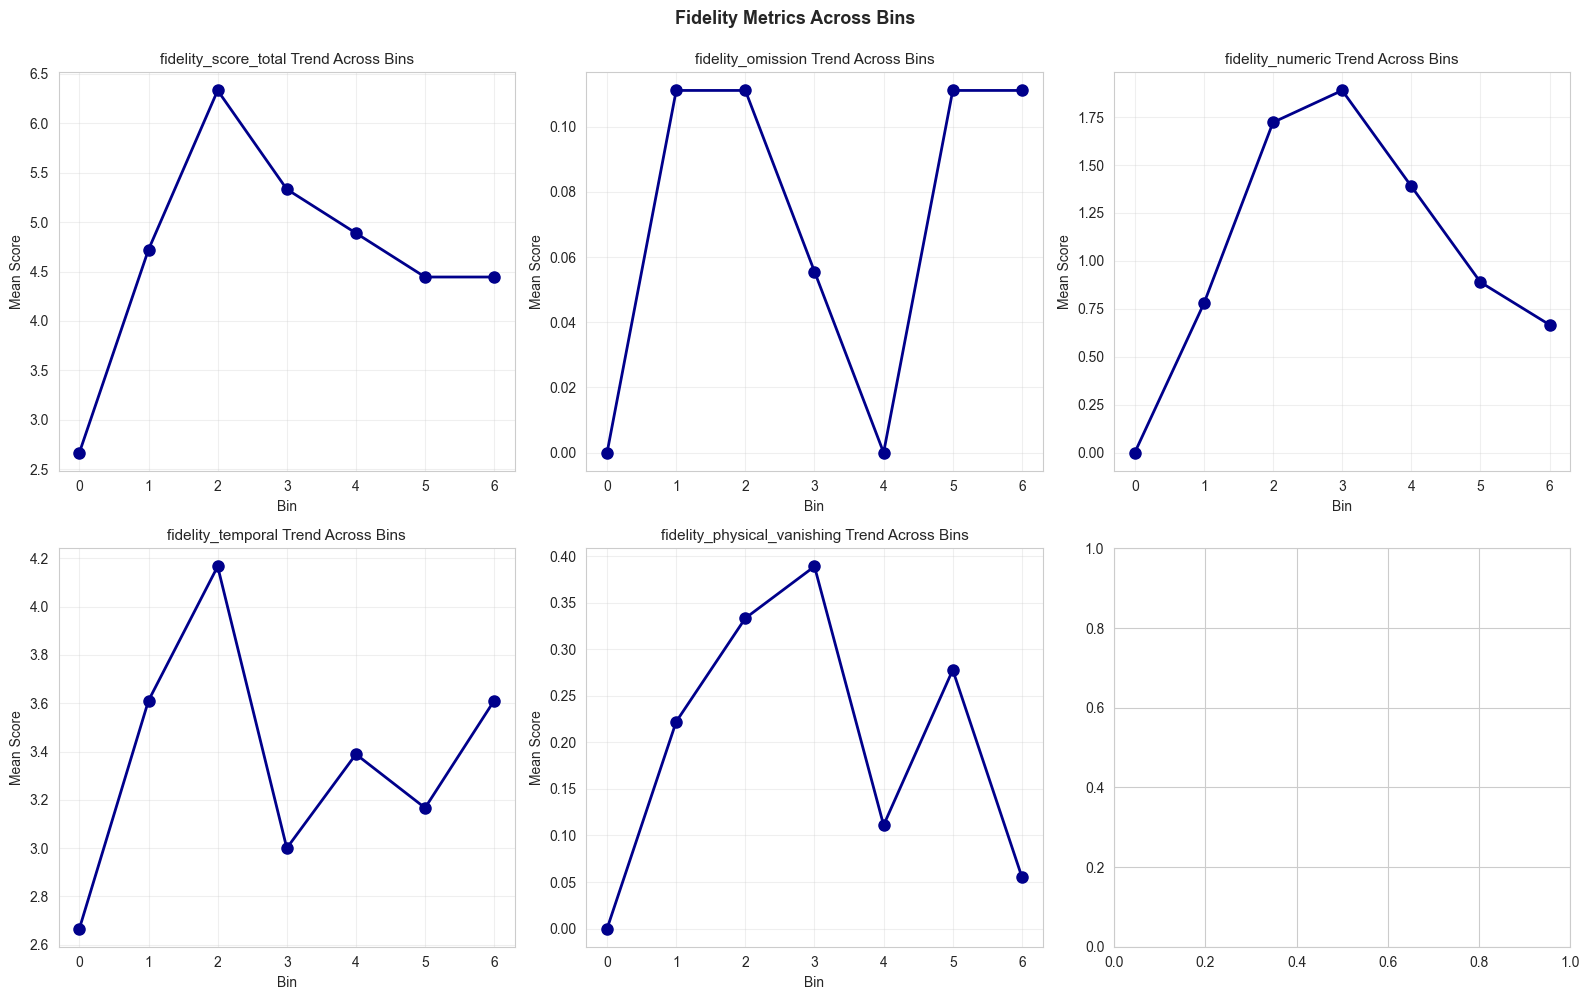

In [14]:
# 7d: Fidelity distributions by success status
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(fidelity_cols[:6]):  # Plot first 6 fidelity columns
    ax = axes[idx]
    veo_data.boxplot(column=col, by='success', ax=ax)
    ax.set_title(f'{col} by Success', fontsize=11)
    ax.set_xlabel('Success (0=Failure, 1=Success)', fontsize=10)
    ax.set_ylabel('Score', fontsize=10)
    plt.sca(ax)
    plt.xticks([1, 2], ['Failure', 'Success'])

plt.suptitle('Fidelity Distributions by Success/Failure Status', y=0.995, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 7e: Stacked bar chart - Failure types by condition
failure_by_cond_type = failures.groupby(['condition', 'failure_type']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(12, 6))
failure_by_cond_type.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_title('Failure Types by Condition', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=11)
ax.set_xlabel('Condition', fontsize=11)
ax.legend(title='Failure Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 7f: Fidelity trends by bin
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(fidelity_cols[:6]):
    ax = axes[idx]
    fidelity_by_bin_plot = veo_data.groupby('bin_y')[col].mean()
    ax.plot(fidelity_by_bin_plot.index, fidelity_by_bin_plot.values, marker='o', linewidth=2, markersize=8, color='darkblue')
    ax.set_title(f'{col} Trend Across Bins', fontsize=11)
    ax.set_xlabel('Bin', fontsize=10)
    ax.set_ylabel('Mean Score', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Fidelity Metrics Across Bins', y=0.995, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Summary Tables & CSV Export

In [15]:
print("\n" + "=" * 60)
print("SUMMARY TABLE 1: GENERATIVE SUCCESS (Main DV)")
print("=" * 60)
print(generative_success.to_string(index=False))

# Export additional summary tables
print("\n--- Exporting Summary Tables to CSV ---")

# Success by condition
success_by_condition.to_csv('../Analysis/success_by_condition.csv', index=False)
print("✓ Analysis/success_by_condition.csv")

# Success by bin
success_by_bin.to_csv('../Analysis/success_by_bin.csv', index=False)
print("✓ Analysis/success_by_bin.csv")

# Failure type distribution
failure_type_dist.to_frame('count').to_csv('../Analysis/failure_type_counts.csv')
print("✓ Analysis/failure_type_counts.csv")

# Failure types by condition
failure_by_condition.to_csv('../Analysis/failure_by_condition.csv', index=False)
print("✓ Analysis/failure_by_condition.csv")

# Fidelity by condition
fidelity_by_condition.to_csv('../Analysis/fidelity_by_condition.csv')
print("✓ Analysis/fidelity_by_condition.csv")

# Fidelity by bin
fidelity_by_bin.to_csv('../Analysis/fidelity_by_bin.csv')
print("✓ Analysis/fidelity_by_bin.csv")

print("\nAll summary tables exported successfully!")
print("\nKey output for downstream analyses:")
print(f"  → Analysis/generative_success.csv (Main Dependent Variable)")
print(f"    Columns: condition, bin, generative_success, n_success, n_total, std_success, ci_lower, ci_upper")


SUMMARY TABLE 1: GENERATIVE SUCCESS (Main DV)
      condition  bin  generative_success  n_success  n_total  std_success  ci_lower  ci_upper
  2Among5Colour    1            0.833333          5        6     0.408248  0.535129  1.131538
  2Among5Colour    2            0.666667          4        6     0.516398  0.289464  1.043869
  2Among5Colour    3            0.333333          2        6     0.516398 -0.043869  0.710536
  2Among5Colour    4            0.333333          2        6     0.516398 -0.043869  0.710536
  2Among5Colour    5            0.166667          1        6     0.408248 -0.131538  0.464871
  2Among5Colour    6            0.500000          3        6     0.547723  0.099917  0.900083
 2Among5ConjRed    1            0.833333          5        6     0.408248  0.535129  1.131538
 2Among5ConjRed    2            0.000000          0        6     0.000000  0.000000  0.000000
 2Among5ConjRed    3            0.166667          1        6     0.408248 -0.131538  0.464871
 2Among5ConjR

## 9. Analysis Summary

In [16]:
print("\n" + "=" * 70)
print("VEO DESCRIPTIVE ANALYSIS - COMPLETE SUMMARY")
print("=" * 70)

print(f"\n📊 Data Overview:")
print(f"   Total Trials: {len(veo_data):,}")
print(f"   Conditions: {veo_data['condition'].nunique()} ({', '.join(sorted(veo_data['condition'].unique()))})")
print(f"   Bins: {veo_data['bin_y'].nunique()}")
print(f"   Overall Success Rate: {overall_success:.1%}")

print(f"\n🎯 Key Finding - Generative Success by Condition × Bin:")
print(f"   Range: {generative_success['generative_success'].min():.3f} to {generative_success['generative_success'].max():.3f}")
print(f"   Mean: {generative_success['generative_success'].mean():.3f}")
print(f"   Std: {generative_success['generative_success'].std():.3f}")

print(f"\n❌ Failure Analysis:")
print(f"   Total Failures: {total_failures:,} ({total_failures/len(veo_data)*100:.1f}%)")
print(f"   Failure Types: {len(failure_type_dist)}")
print(f"   Most Common: {failure_type_dist.index[0]} ({failure_type_dist.iloc[0]} cases)")

print(f"\n📈 Fidelity Metrics:")
print(f"   Number of metrics: {len(fidelity_cols)}")
for col in fidelity_cols:
    print(f"   - {col}: M={veo_data[col].mean():.3f}, SD={veo_data[col].std():.3f}")

print(f"\n📁 Output Files Generated:")
print(f"   ✓ Analysis/generative_success.csv (Main Dependent Variable)")
print(f"   ✓ Analysis/success_by_condition.csv")
print(f"   ✓ Analysis/success_by_bin.csv")
print(f"   ✓ Analysis/failure_type_counts.csv")
print(f"   ✓ Analysis/failure_by_condition.csv")
print(f"   ✓ Analysis/fidelity_by_condition.csv")
print(f"   ✓ Analysis/fidelity_by_bin.csv")

print(f"\n✅ Analysis complete! Ready for hypothesis testing and modeling.")
print("=" * 70)


VEO DESCRIPTIVE ANALYSIS - COMPLETE SUMMARY

📊 Data Overview:
   Total Trials: 114
   Conditions: 4 (2Among5Colour, 2Among5ConjRed, 2Among5NoColour, NoDistractors)
   Bins: 7
   Overall Success Rate: 29.8%

🎯 Key Finding - Generative Success by Condition × Bin:
   Range: 0.000 to 1.000
   Mean: 0.298
   Std: 0.345

❌ Failure Analysis:
   Total Failures: 80 (70.2%)
   Failure Types: 4
   Most Common: new_generation (61 cases)

📈 Fidelity Metrics:
   Number of metrics: 5
   - fidelity_score_total: M=4.904, SD=1.960
   - fidelity_omission: M=0.079, SD=0.271
   - fidelity_numeric: M=1.158, SD=0.965
   - fidelity_temporal: M=3.447, SD=1.383
   - fidelity_physical_vanishing: M=0.219, SD=0.436

📁 Output Files Generated:
   ✓ Analysis/generative_success.csv (Main Dependent Variable)
   ✓ Analysis/success_by_condition.csv
   ✓ Analysis/success_by_bin.csv
   ✓ Analysis/failure_type_counts.csv
   ✓ Analysis/failure_by_condition.csv
   ✓ Analysis/fidelity_by_condition.csv
   ✓ Analysis/fidelity_b